<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Cuasal_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. INSTALAR DOWHY

!pip install dowhy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 71.1 MB/s eta 0:00:00


In [3]:
# 2. IMPORTAR BIBLIOTECAS


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from dowhy import CausalModel

In [12]:
# 3. CREAR DATOS SIMULADOS

np.random.seed(42)

n = 1000

# Variables de confusión
experiencia = np.random.normal(5, 2, n)
motivacion = np.random.normal(5, 2, n)

# Tratamiento:
# 1 = recibió capacitación
# 0 = no recibió capacitación
prob_capacitacion = 1 / (
    1 + np.exp(-(0.5 * experiencia + 0.8 * motivacion - 5))
)

capacitacion = np.random.binomial(1, prob_capacitacion)

# Resultado:
# El desempeño depende de:
# - Experiencia
# - Motivación
# - Capacitación
desempeno = (
    50
    + 3 * experiencia
    + 5 * motivacion
    + 10 * capacitacion
    + np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "experiencia": experiencia,
    "motivacion": motivacion,
    "capacitacion": capacitacion,
    "desempeno": desempeno
})

df.head()

,experiencia,motivacion,capacitacion,desempeno
0,5.993428,7.798711,1,119.839478
1,4.723471,6.849267,1,99.487419
2,6.295377,5.119261,1,102.684287
3,8.046060,3.706126,1,104.174348
4,4.531693,6.396447,1,106.496485


In [5]:
# 4. DEFINIR EL GRAFO CAUSAL


grafo = """
digraph {
    experiencia -> capacitacion;
    experiencia -> desempeno;

    motivacion -> capacitacion;
    motivacion -> desempeno;

    capacitacion -> desempeno;
}
"""

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


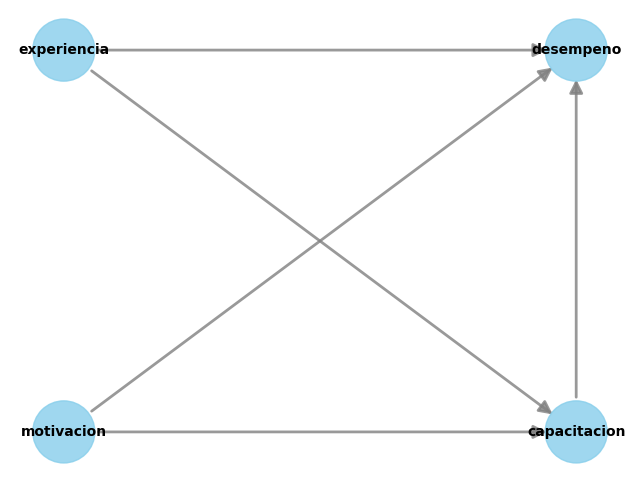

In [6]:
# 5. CREAR EL MODELO CAUSAL


modelo = CausalModel(
    data=df,
    treatment="capacitacion",
    outcome="desempeno",
    graph=grafo
)

modelo.view_model()

In [13]:
# 6. IDENTIFICAR EL EFECTO CAUSAL


estimando = modelo.identify_effect()

print(estimando)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                            
───────────────(E[desempeno|motivacion,experiencia])
d[capacitacion]                                     
Estimand assumption 1, Unconfoundedness: If U→{capacitacion} and U→desempeno then P(desempeno|capacitacion,motivacion,experiencia,U) = P(desempeno|capacitacion,motivacion,experiencia)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                            
───────────────(E[desempeno|motivacion,experiencia])
d[capacitacion]                                     
Estimand assumption 1, Unconfoundedness: If U→{capacitacion} and U→desempeno then P(desempeno|capacitacion,motivacion,experiencia,U) = P(desempeno|capacitacion,motivacion,experiencia)

In [15]:
estimando.backdoor_variables

{'backdoor1': ['motivacion', 'experiencia'],
 'backdoor2': ['motivacion', 'experiencia'],
 'backdoor': ['motivacion', 'experiencia']}

In [17]:
estimando.estimands

{'backdoor1': {'estimand': Derivative(Expectation(desempeno|motivacion,experiencia), [capacitacion]),
  'assumptions': {'Unconfoundedness': 'If U→{capacitacion} and U→desempeno then P(desempeno|capacitacion,motivacion,experiencia,U) = P(desempeno|capacitacion,motivacion,experiencia)'}},
 'backdoor2': {'estimand': Derivative(Expectation(desempeno|motivacion,experiencia), [capacitacion]),
  'assumptions': {'Unconfoundedness': 'If U→{capacitacion} and U→desempeno then P(desempeno|capacitacion,motivacion,experiencia,U) = P(desempeno|capacitacion,motivacion,experiencia)'}},
 'backdoor': {'estimand': Derivative(Expectation(desempeno|motivacion,experiencia), [capacitacion]),
  'assumptions': {'Unconfoundedness': 'If U→{capacitacion} and U→desempeno then P(desempeno|capacitacion,motivacion,experiencia,U) = P(desempeno|capacitacion,motivacion,experiencia)'}},
 'iv': None,
 'frontdoor': None,
 'general1': {'estimand': Derivative(Expectation(desempeno|motivacion,experiencia), [capacitacion]),
  '

In [18]:
# 7. ESTIMAR EL EFECTO CAUSAL


efecto = modelo.estimate_effect(
    estimando,
    method_name="backdoor.linear_regression"
)

print("Efecto causal estimado:")
print(efecto.value)

Efecto causal estimado:
10.988222009480737


In [19]:
efecto.estimator.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              desempeno   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     2660.
Date:                Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:48:19   Log-Likelihood:                -3060.5
No. Observations:                1000   AIC:                             6129.
Df Residuals:                     996   BIC:                             6149.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.4091      0.635     77.851      0.000      48.164      50.655
x1            10.9882      0.437     25.139      0.000      10.130      11.846
x2             4.9838      0.094     52.935      0.000       4.799       5.169
x3             2.9861      0.089     33.520      0.000       2.811       3.161
==============================================================================
Omnibus:                        0.345   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.841   Jarque-Bera (JB):                0.433
Skew:                           0.020   Prob(JB):                        0.805
Kurtosis:                       2.906   Cond. No.                         29.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
# 8. PRUEBA DE REFUTACIÓN


refutacion = modelo.refute_estimate(
    estimando,
    efecto,
    method_name="random_common_cause"
)

print(refutacion)

Refute: Add a random common cause
Estimated effect:10.988222009480737
New effect:10.989119980010065
p value:0.8799999999999999



In [10]:
# 9. PRUEBA PLACEBO


refutacion_placebo = modelo.refute_estimate(
    estimando,
    efecto,
    method_name="placebo_treatment_refuter"
)

print(refutacion_placebo)

Refute: Use a Placebo Treatment
Estimated effect:10.988222009480737
New effect:-0.12254159783931257
p value:0.76



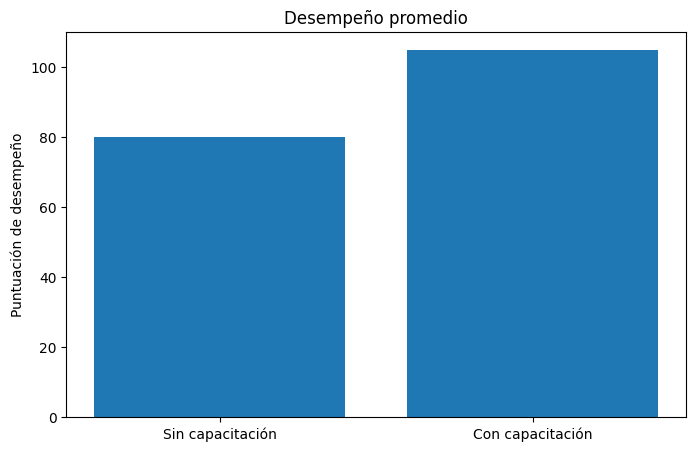

In [11]:
# 10. COMPARAR DESEMPEÑO


promedios = df.groupby("capacitacion")["desempeno"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Sin capacitación", "Con capacitación"],
    promedios.values
)

plt.title("Desempeño promedio")
plt.ylabel("Puntuación de desempeño")

plt.show()